In [103]:
import math
import numpy as np
import dateutil as du
import datetime
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from metpy.plots import StationPlot
from metpy.units import units
import modules.URLhandler as URLhandler

In [104]:
api_urlForecast = "https://api.pirateweather.net/forecast/40fIKUFaJxn5cW5qweU5ZEAVYTGO87vK/42.00%2C-93.62?extend=hourly"

dataForecast = URLhandler.URLcollector(api_urlForecast, "forecast")

dataHourly = dataForecast['hourly']['data']
currentTime = dataForecast['currently']['time']

In [121]:
print(dataHourly)

[{'time': 1703653200, 'icon': 'partly-cloudy-night', 'summary': 'Partly Cloudy', 'precipIntensity': 0.0, 'precipProbability': 0.0, 'precipIntensityError': 0.0, 'precipAccumulation': 0.0, 'precipType': 'none', 'temperature': 31.62, 'apparentTemperature': 26.52, 'dewPoint': 29.82, 'humidity': 0.91, 'pressure': 978.1, 'windSpeed': 5.08, 'windGust': 13.96, 'windBearing': 58, 'cloudCover': 0.54, 'uvIndex': 0.0, 'visibility': 8.64, 'ozone': 357.76}, {'time': 1703656800, 'icon': 'cloudy', 'summary': 'Cloudy', 'precipIntensity': 0.0, 'precipProbability': 0.0, 'precipIntensityError': 0.0, 'precipAccumulation': 0.0, 'precipType': 'none', 'temperature': 31.73, 'apparentTemperature': 25.51, 'dewPoint': 29.82, 'humidity': 0.91, 'pressure': 979.1, 'windSpeed': 6.48, 'windGust': 16.34, 'windBearing': 53, 'cloudCover': 0.76, 'uvIndex': 0.0, 'visibility': 8.7, 'ozone': 358.03}, {'time': 1703660400, 'icon': 'clear-night', 'summary': 'Clear', 'precipIntensity': 0.0018, 'precipProbability': 0.02, 'precipI

In [122]:
listOfTimestamps = []
listOfTemperatures = []
listOfApparentChill = []
listOfApparentHeat = []
listOfDewPoints = []
listOfWindsForecast = []
listOfWindsDirection = []

# for i in dataHourly:
#     listOfTimestamps.append(i['time'])

#     listOfTemperatures.append(i['temperature'])
#     if(i['apparentTemperature'] <= i['temperature']):
#         listOfApparentChill.append(i['apparentTemperature'])
#         listOfApparentHeat.append(i['temperature'])
#     else:
#         listOfApparentChill.append(i['temperature'])
#         listOfApparentHeat.append(i['apparentTemperature'])
#     listOfDewPoints.append(i['dewPoint'])
#     listOfWindsForecast.append(i['windSpeed'])
#     listOfWindsDirection.append(i['windBearing'])

for i in dataHourly:
    listOfTimestamps.append(i['time'])

    listOfTemperatures.append(i['temperature'])
    if(i['apparentTemperature'] <= i['temperature']):
        listOfApparentChill.append(i['apparentTemperature'])
        listOfApparentHeat.append(i['temperature'])
    else:
        listOfApparentChill.append(i['temperature'])
        listOfApparentHeat.append(i['apparentTemperature'])
    listOfDewPoints.append(i['dewPoint'])
    listOfWindsForecast.append(i['windSpeed'])
    listOfWindsDirection.append(i['windBearing'])

In [123]:
listOfWindXandYFore = []
count1 = 0
for i in listOfWindsDirection:
    listOfWindXandYFore.append(((listOfWindsForecast[count1]*np.sin(listOfWindsDirection[count1] * np.pi / 180)), \
                                (listOfWindsForecast[count1]*np.cos(listOfWindsDirection[count1] * np.pi / 180))))
    
    count1 += 1

In [124]:
print(listOfWindXandYFore)

[(-1.1059916678344313, -6.982956568007625), (0.5133473247837094, -5.867586771760381), (3.1146965890289553, -6.679488390460111), (3.8883520720191154, -7.972303190673611), (3.5501690877204433, -9.75400940375773), (3.8488717781165245, -10.026653780579947), (4.433265565659938, -9.507168686014458), (2.735717306733647, -10.20983598387545), (2.544196424629111, -11.020125432721011), (3.1189429196995646, -9.058067954241455), (4.535365092398073, -8.901155176641794), (6.09451080181815, -9.384723655309296), (5.464480410220597, -7.25161043122942), (3.533271443119963, -7.244280013171287), (5.233981126494408, -8.059624157955525), (4.353025487615537, -8.925024879750728), (5.649967681763297, -9.40312528870217), (5.87143405397462, -9.771707228004079), (6.263348902672809, -9.644711531372378), (6.386472128884675, -10.628874528706191), (6.432187003527467, -9.90469940743546), (5.806774916317211, -12.45266899388357), (7.363519753403163, -11.338826078622134), (8.272039714680329, -13.23803078100181), (8.034999

In [125]:
listOfDatetimes = [datetime.datetime.fromtimestamp(x) for x in listOfTimestamps]

currentDay = currentTime/86400


In [126]:
# The upper and lower bounds are used to give enough clearance on the plot for the precip type boxes and the wind barbs.
# Six is a good compromise between the space needed and making the plot clear across a wide range of temperatures.

# This finds the minimum and maximum of a list that contains NaNs. When using the built-in min and max functions,
# nan sometimes breaks the functions when NaNs are present in the list.
def minNoNaN(inputList):
    return min(filter(lambda x: not math.isnan(x), inputList))
def maxNoNaN(inputList):
    return max(filter(lambda x: not math.isnan(x), inputList))


tempsLowerBound = min(minNoNaN(listOfDewPoints), minNoNaN(listOfApparentChill)) - 6
tempsUpperBound = maxNoNaN((max(listOfTemperatures), max(listOfApparentHeat))) + 6

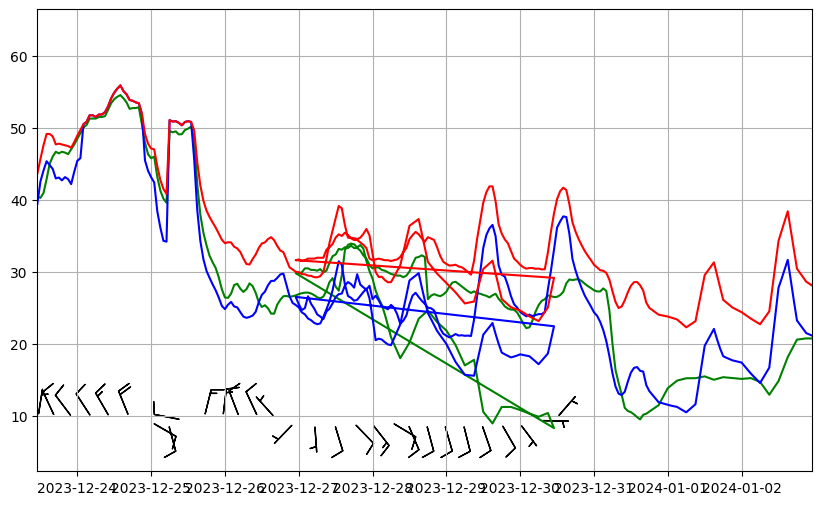

In [127]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(listOfDatetimes, listOfDewPoints, color='green', label="Dew Point")
ax.plot(listOfDatetimes, listOfApparentChill, color='blue', label="Feels Like")
ax.plot(listOfDatetimes, listOfTemperatures, color='red', label="Temperature")

# The bounds of the plot are set as 2 days before now and the ending timestamp, and the upper and lower temp bounds.
# The lower and upper bounds are the temperature mins and maxs, with a constant offset.
plt.axis([listOfDatetimes[0], listOfDatetimes[-1], tempsLowerBound, tempsUpperBound])

# Adjustable sizing for the size and location of the precip bar at the top of the chart.
# Also determines the size of the wind barbs. 
# This keeps everything consistent between cities with different amounts of daily variation.
axisHeight = ax.get_ylim()[1] - ax.get_ylim()[0]
barbPlacement = axisHeight / 9
pTypeSize = axisHeight / 18
pTypePlacement = axisHeight / 10
pTextPlacement = axisHeight / 13

barbLength = 6

# The wind barbs need to be graphed after the night boxes, otherwise they tend to get covered up.
# This is the number of hours between wind barbs.
hoursBetweenWind = 6
# This specifically plots every sixth wind barb that is forecasted.
count2 = 0
for j in dataHourly:
    # Plots a wind barb every 6 units, which is equivalent to every 6 hours.
    if(count2 % hoursBetweenWind == 0):
        stationplot = StationPlot(ax, listOfDatetimes[count2], tempsLowerBound+barbPlacement, clip_on=True, length=barbLength)
        stationplot.plot_barb(listOfWindXandYFore[count2][0], listOfWindXandYFore[count2][1])
        
    count2 += 1
ax.grid(True)
